In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import json
from pathlib import Path
from scipy.optimize import curve_fit
import statsmodels.api as sm

# Repo root: when run from figures_notebooks/, go up one level
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'figures_notebooks' else Path.cwd()

In [12]:
def _load_ml_data_from_ml_data_folder(n, noise_type, gamma, stat_type, ml_alpha_pattern):
    """
    Load ML accuracy from ml_data via scenario1_train_results.json (same as plot_method_centric_raw).
    Returns (mean_data, yerr) with 14 points: interpolate from 7 (k, acc) to k_target.
    """
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    channel_type = 'thermal' if noise_type == 'relaxation' else noise_type  # dephasing, depolarizing
    q_suffix = 'q_11_12' if n >= 11 else 'q_5_10'
    if ml_alpha_pattern == 'all_ones':
        exp_name = f"exp_s1_fixed_alpha_all_ones_fixed_y_all_zeros_{q_suffix}"
    else:
        exp_name = f"exp_s1_fixed_alpha_half_ones_leading_fixed_y_all_zeros_{q_suffix}"
    results_file = REPO_ROOT / "ml_data" / exp_name / "scenario1_train_results.json"
    if not results_file.exists():
        raise FileNotFoundError(f"Not found: {results_file}")
    with open(results_file) as f:
        data = json.load(f)
    for run in data['runs']:
        meta = run['meta']
        if meta['n'] != n:
            continue
        cc = meta['channel_config']
        if cc['type'] != channel_type or cc['strength'] != gamma:
            continue
        k_list, y_list, q1_list, q3_list = [], [], [], []
        for per in run['per_nps']:
            nps = per['nps']
            k_list.append(np.log2(nps) / n)
            accs = [r['logreg']['val']['acc'] for r in per['independent_runs']['per_run']]
            med = float(np.median(accs))
            q1, q3 = np.percentile(accs, [25, 75])
            y_list.append(med)
            q1_list.append(q1)
            q3_list.append(q3)
        k_arr = np.array(k_list)
        mean_data = np.interp(k_target, k_arr, np.array(y_list))
        lower_data = np.interp(k_target, k_arr, np.array(q1_list))
        higher_data = np.interp(k_target, k_arr, np.array(q3_list))
        yerr = [lower_data, higher_data]
        return mean_data, yerr
    raise FileNotFoundError(f"No run for n={n}, {noise_type}, gamma={gamma} in {results_file}")

def get_data_to_plot_alphas_2(n, noise_type, gamma, method_type='hypergraph', stat_type='iqr', ml_alpha_pattern='all_ones'):
    """
    Load data for given (n, noise_type, gamma).
    For method_type='ml': loads from ml_data folder (all_ones or half_ones_leading exp).
    For hypergraph/shadow_surrogates: loads from paper_data_2.
    """
    if method_type == 'ml':
        try:
            return _load_ml_data_from_ml_data_folder(n, noise_type, gamma, stat_type, ml_alpha_pattern)
        except FileNotFoundError as e:
            if ml_alpha_pattern == 'half_ones':
                return get_data_to_plot_alphas_2(n, noise_type, gamma, method_type, stat_type, ml_alpha_pattern='all_ones')
            raise e

    general_dir = REPO_ROOT / "paper_data_2" / method_type
    fold = general_dir / f"{n}/{stat_type}"
    if stat_type == 'stats':
        mean_file = fold / f"alphas_means_{noise_type}_{gamma}.npy"
        lower_file = fold / f"alphas_stds_lower_{noise_type}_{gamma}.npy"
        higher_file = fold / f"alphas_stds_higher_{noise_type}_{gamma}.npy"
    elif stat_type == 'iqr':
        mean_file = fold / f"alphas_medians_{noise_type}_{gamma}.npy"
        lower_file = fold / f"alphas_iqrs_1_{noise_type}_{gamma}.npy"
        higher_file = fold / f"alphas_iqrs_3_{noise_type}_{gamma}.npy"
    else:
        raise ValueError("stat_type must be either 'stats' or 'iqr'")

    if not mean_file.exists():
        raise FileNotFoundError(f"No file found at {mean_file}")
    if not lower_file.exists():
        raise FileNotFoundError(f"No file found at {lower_file}")
    if not higher_file.exists():
        raise FileNotFoundError(f"No file found at {higher_file}")

    mean_data = np.load(mean_file)
    lower_data = np.load(lower_file)
    higher_data = np.load(higher_file)
    yerr = [lower_data, higher_data]
    return mean_data, yerr

In [13]:
def _fit_meta_scaling(noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern='all_ones'):
    """
    Extracts empirical slopes/intercepts across all available n,
    and returns the linear scaling polynomials for m(n) and x0(n).
    """
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    n_qubits = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
    valid_n, slopes, intercepts = [], [], []

    for n_q in n_qubits:
        try:
            y_vals, yerr = get_data_to_plot_alphas_2(n_q, noise_type, gamma, method_type, stat_type, ml_alpha_pattern)
            eps = 1e-4
            y_clipped_all = np.clip(y_vals, 0.5 + eps, 1.0 - eps)
            visibility_all = 2.0 * y_clipped_all - 1.0
            v_logit2_all = np.log2(visibility_all / (1.0 - visibility_all))
            y_err_avg = (yerr[0] + yerr[1]) / 2.0
            v_err_all = 2.0 * y_err_avg
            v_err_clipped = np.clip(v_err_all, 1e-5, None)
            weights_all = (np.log(2)**2 * visibility_all**2 * (1.0 - visibility_all)**2) / (v_err_clipped**2)

            breakout_indices = np.where(y_vals > 0.55)[0]
            start_idx = max(0, breakout_indices[0] - 1) if len(breakout_indices) > 0 else 0
            plateau_indices = np.where(y_vals >= 0.99)[0]
            end_idx = plateau_indices[0] if len(plateau_indices) > 0 else len(y_vals) - 1
            if start_idx >= end_idx:
                start_idx, end_idx = 0, len(y_vals) - 1
            valid_idx = np.arange(start_idx, end_idx + 1)
            if len(valid_idx) < 2:
                continue

            k_valid = k_target[valid_idx]
            v_logit2_valid = v_logit2_all[valid_idx]
            weights_valid = weights_all[valid_idx]
            X = sm.add_constant(k_valid)
            if regress_type.lower() == 'wls':
                model = sm.WLS(v_logit2_valid, X, weights=weights_valid)
            elif regress_type.lower() == 'ols':
                model = sm.OLS(v_logit2_valid, X)
            else:
                raise ValueError("regress_type must be 'wls' or 'ols'")
            results = model.fit()
            intercepts.append(results.params[0])
            slopes.append(results.params[1])
            valid_n.append(n_q)
        except FileNotFoundError:
            continue

    m_poly = np.polyfit(valid_n, slopes, 1)
    int_poly = np.polyfit(valid_n, intercepts, 1)
    return m_poly, int_poly

def k_hat(target_accuracy, n_array, noise_type, gamma, stat_type='iqr', method_type='hypergraph', regress_type='wls', ml_alpha_pattern='all_ones'):
    """Vectorized: Predicts the required k value for a target accuracy across an array of n values."""
    n_array = np.asarray(n_array)
    m_poly, int_poly = _fit_meta_scaling(noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern)
    m_n = np.polyval(m_poly, n_array)
    x0_n = np.polyval(int_poly, n_array)
    eps = 1e-4
    A_clipped = np.clip(target_accuracy, 0.5 + eps, 1.0 - eps)
    visibility = 2.0 * A_clipped - 1.0
    target_logit2 = np.log2(visibility / (1.0 - visibility))
    k_predicted = (target_logit2 - x0_n) / m_n
    return k_predicted

def nps_hat(target_accuracy, n_array, noise_type, gamma, stat_type='iqr', method_type='hypergraph', regress_type='wls', ml_alpha_pattern='all_ones'):
    """Vectorized: Predicts the raw number of samples (n_ps) required across an array of n values."""
    n_array = np.asarray(n_array)
    k_predicted = k_hat(target_accuracy, n_array, noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern)
    nps_predicted = 2**(k_predicted * n_array)
    return nps_predicted

In [18]:
from pathlib import Path

# 68% CI unified CSVs: |α|=n_q (alpha_nq) vs |α|=n_q/2 (alpha_nq2) — same basename as generate_plots.txt
_UNIFIED_CSV = "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv"
CSV_RELAX_NQ = REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq" / "ci68_IT" / _UNIFIED_CSV
CSV_RELAX_NQ2 = REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq2" / "ci68_IT" / _UNIFIED_CSV


def plot_fig1_relaxation_mf_onepanel(
    save_pdf=True,
    figsize=(4.8, 3.0),
):
    """
    Fig. 1: curve-fitting unified CSVs via plot_mf_onepanel_relaxation_p01.plot_onepanel
    (thermal relaxation p=0.1, η ∈ {1%, 5%}, device A only, readout 0.1%).

    Overlays |α|=n_q (red) and |α|=n_q/2 (green); legends: MF method, η, and |α| (no device legend).

    manuscript_fig1 styling: see plot_mf_onepanel_relaxation_p01.py (FIG1_MS_*: e.g. n_q to 52, y floor 1e3).
    """
    if not CSV_RELAX_NQ.is_file():
        raise FileNotFoundError(CSV_RELAX_NQ)
    if not CSV_RELAX_NQ2.is_file():
        raise FileNotFoundError(CSV_RELAX_NQ2)

    plt.style.use(str(REPO_ROOT / "figures_notebooks" / "single_column.mplstyle"))

    # Always load the plotting module from disk (avoids stale Jupyter imports after .py edits).
    import importlib.util

    _plot_py = REPO_ROOT / "curve_fitting" / "plot_mf_onepanel_relaxation_p01.py"
    _spec = importlib.util.spec_from_file_location(
        "plot_mf_onepanel_relaxation_p01_live",
        _plot_py,
    )
    _mf = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mf)
    _load_rows = _mf._load_rows
    plot_onepanel = _mf.plot_onepanel

    rows_nq = _load_rows(CSV_RELAX_NQ)
    rows_nq2 = _load_rows(CSV_RELAX_NQ2)
    fig, ax = plot_onepanel(
        rows_nq,
        channel="relaxation",
        amplitude=0.1,
        etas=[0.01, 0.05],
        devices=["A"],
        readout_error="0%",
        readout_by_device={"A": "0.1%"},
        out_png=None,
        out_pdf=None,
        figsize=figsize,
        close_fig=False,
        manuscript_fig1=True,
        manuscript_dual_alpha_rows={"nq": rows_nq, "nq2": rows_nq2},
    )
    if save_pdf:
        from matplotlib.transforms import Bbox
        from matplotlib.legend import Legend

        out = REPO_ROOT / "figures_manuscript" / "fig1.pdf"
        out.parent.mkdir(parents=True, exist_ok=True)
        plt.tight_layout()
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        legend_artists = [obj for obj in fig.findobj() if isinstance(obj, Legend)]
        _bbox = fig.get_tightbbox(renderer, bbox_extra_artists=legend_artists or None)
        _bbox = _bbox.padded(0.08)
        _pts = _bbox.get_points().copy()
        _pts[1, 0] += 0.22
        _pts[1, 1] += 0.1
        fig.savefig(
            str(out),
            bbox_inches=Bbox(_pts),
            pad_inches=0,
            bbox_extra_artists=legend_artists or None,
        )
    plt.show()
    plt.close(fig)


Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


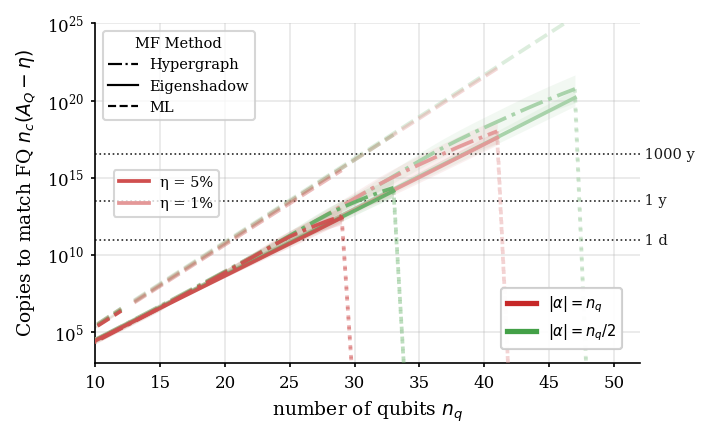

In [19]:
plot_fig1_relaxation_mf_onepanel()